# 18 - CNN Front-Only 7-Class

**Dataset:** Front-only 7-Class
**3 Skenario:** B1 (Baseline), B2 (Class Weights), B3 (Weights + Augmentasi)

In [1]:
import sys, os, json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import DataLoader
from collections import Counter

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import EmotionCNN
from training.utils import (
    EmotionImageDataset, EmotionLandmarkDataset, EmotionMultimodalDataset,
    get_class_weights, train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)})")

Device: cuda
GPU: Tesla T4)


In [2]:
DATASET_DIR = PROJECT_ROOT / "data" / "dataset_frontonly"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "frontonly" / "7class"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 50
LR = 0.0001
PATIENCE = 15
NUM_CLASSES = 7
EMOTIONS = ["neutral", "happy", "sad", "angry", "fearful", "disgusted", "surprised"]

print(f"Dataset: {DATASET_DIR}")
print(f"Output: {OUTPUT_DIR}")

Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/7class


In [3]:
print("Loading image data...")
def load_dataloaders(dataset_dir, batch_size=32):
    train_ds = EmotionImageDataset(dataset_dir / "X_train_images.npy", dataset_dir / "y_train.npy")
    val_ds = EmotionImageDataset(dataset_dir / "X_val_images.npy", dataset_dir / "y_val.npy")
    test_ds = EmotionImageDataset(dataset_dir / "X_test_images.npy", dataset_dir / "y_test.npy")
    train_l = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_l = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_l = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    y = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y.tolist())
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    for i, e in enumerate(EMOTIONS): print(f"  {e:>10s}: {counts.get(i, 0)}")
    return train_l, val_l, test_l

train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Loading image data...


Train: 5348 | Val: 707 | Test: 1036
     neutral: 4192
       happy: 660
         sad: 382
       angry: 42
     fearful: 7
   disgusted: 16
   surprised: 49


## Skenario B1: Baseline

Model parameters: 26,999,463

Training CNN B1 - Baseline (Front-Only)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.3018     0.5987     0.8284    0.9392   0.1498   0.000100  (36.3s)


     2      0.7235     0.7981     0.5079    0.9392   0.1498   0.000100  (35.5s)


     3      0.6241     0.8067     0.5234    0.9406   0.1832   0.000100  (35.2s)


     4      0.5672     0.8199     0.4589    0.9123   0.1556   0.000100  (36.1s)


...

    16      0.3629     0.8712     0.5965    0.7270   0.1952   0.000050  (33.8s)


    17      0.3460     0.8820     0.5670    0.7539   0.1951   0.000050  (33.9s)


    18      0.3439     0.8777     0.5812    0.7185   0.1925   0.000050  (33.8s)


    19      0.3292     0.8850     0.5299    0.8091   0.2042   0.000050  (33.8s)


    20      0.3270     0.8818     0.6288    0.7383   0.1897   0.000050  (33.8s)

Early stopping at epoch 20. Best epoch: 5 (val_f1=0.2233)

Best: epoch 5, val_acc=0.9038, val_f1=0.2233
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/7class/cnn_b1.pth


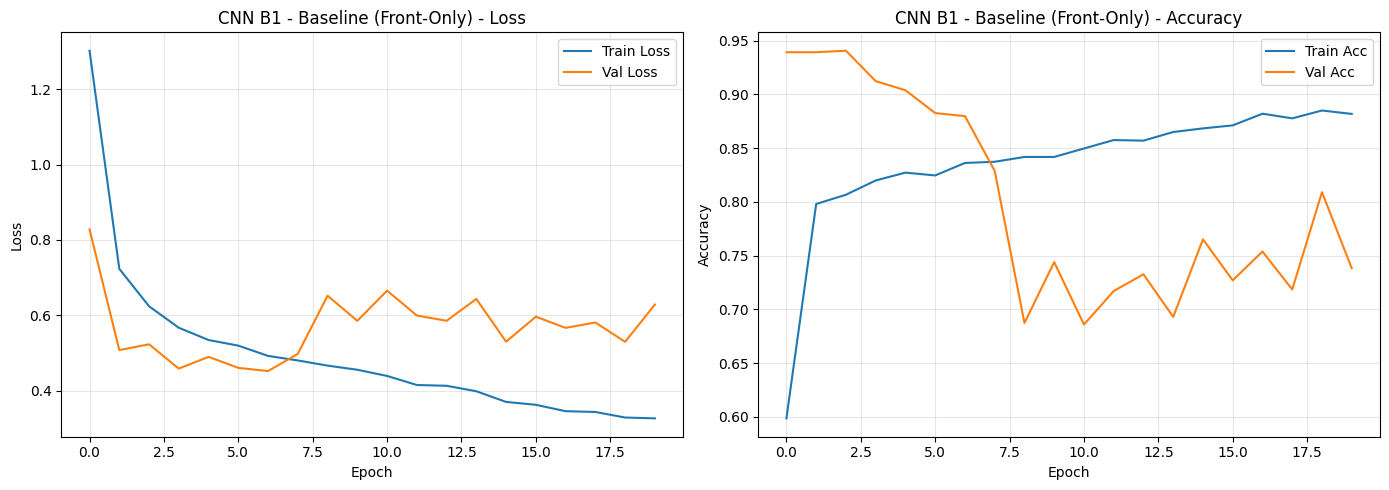

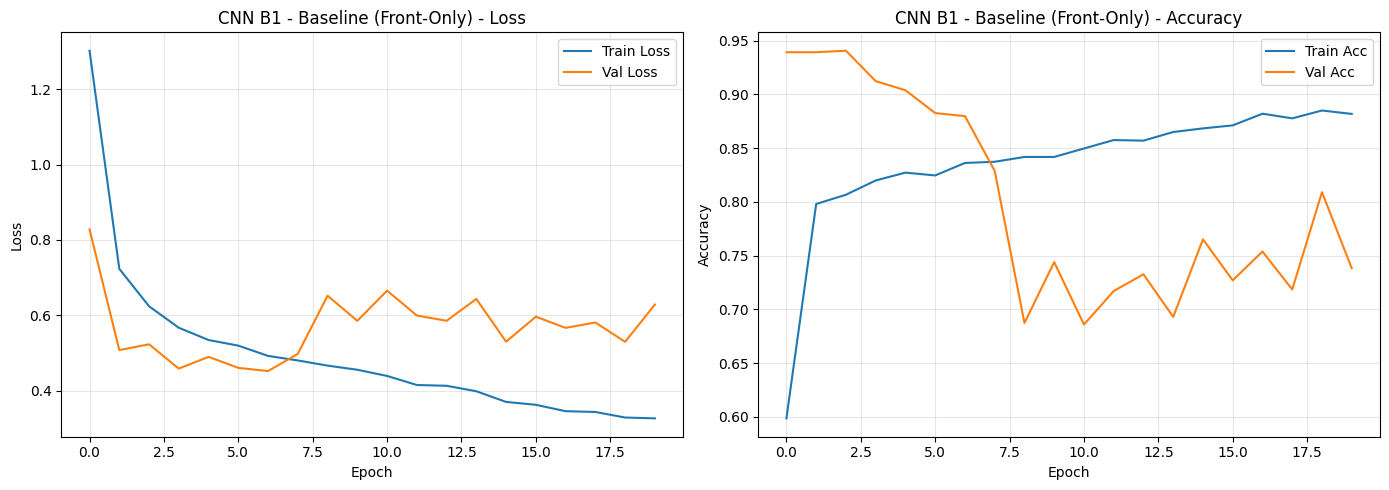

In [4]:
# B1: Baseline
criterion = nn.CrossEntropyLoss()

model = EmotionCNN(num_classes=NUM_CLASSES).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-7)

print("\nTraining CNN B1 - Baseline (Front-Only)...")
history, best_epoch = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "cnn_b1.pth"))

plot_training_history(history, "CNN B1 - Baseline (Front-Only)")

EVALUASI B1 - BASELINE


Test Loss: 0.4106
Test Accuracy: 0.9180
Test Macro F1: 0.1374
Test Weighted F1: 0.9110

Classification Report:
              precision    recall  f1-score   support

     neutral       0.95      0.97      0.96       981
       happy       0.00      0.00      0.00        10
         sad       0.00      0.00      0.00        29
       angry       0.00      0.00      0.00        10
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         3
   surprised       0.00      0.00      0.00         2

    accuracy                           0.92      1036
   macro avg       0.14      0.14      0.14      1036
weighted avg       0.90      0.92      0.91      1036



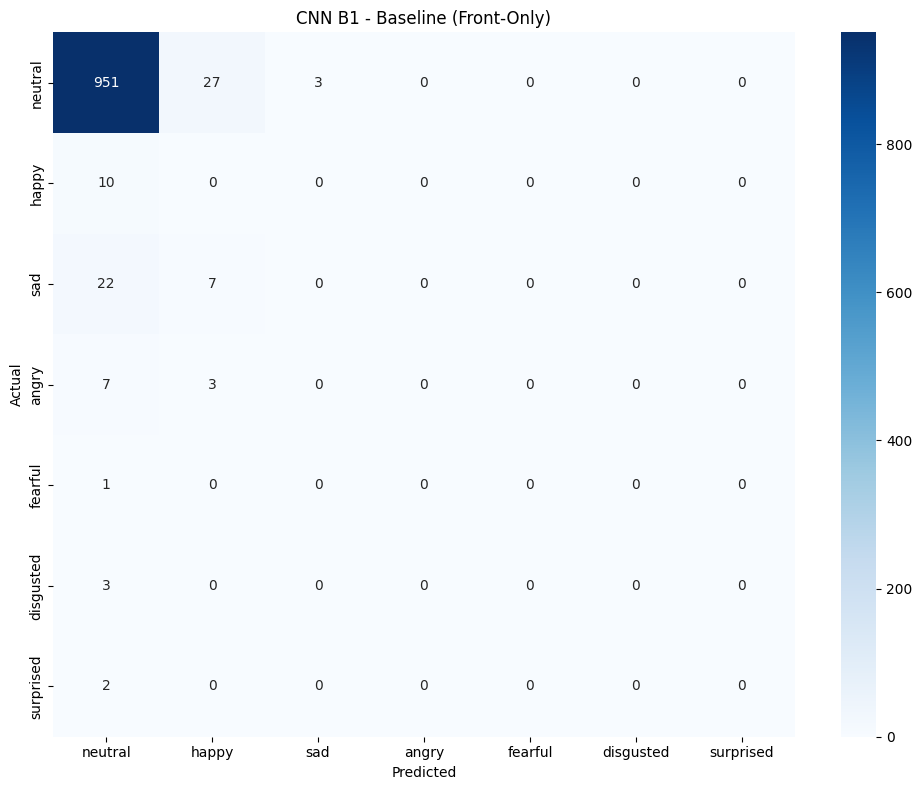

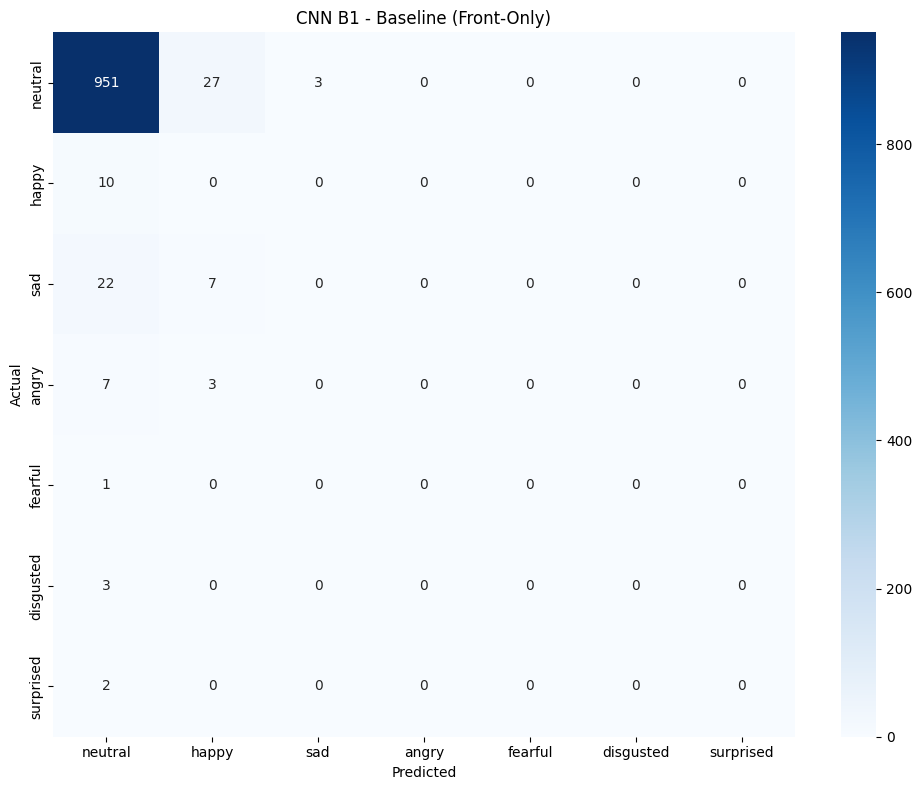

In [5]:
# Evaluate B1
model.load_state_dict(torch.load(OUTPUT_DIR / "cnn_b1.pth", map_location=device, weights_only=True))
print("=" * 60)
print("EVALUASI B1 - BASELINE")
print("=" * 60)
results_b1 = full_evaluation(model, test_loader, criterion, device, "cnn", EMOTIONS)
plot_confusion_matrix(results_b1["confusion_matrix"], "CNN B1 - Baseline (Front-Only)", EMOTIONS)

## Skenario B2: Class Weights

Class weights: None


Model parameters: 26,999,463

Training CNN B2 - Class Weights (Front-Only)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.2803     0.6049     0.7593    0.9378   0.1383   0.000100  (35.5s)


     2      0.7321     0.7926     0.5590    0.9378   0.1383   0.000100  (33.8s)


     3      0.6221     0.8042     0.5637    0.9434   0.2311   0.000100  (33.7s)


...

    27      0.2595     0.9063     0.4874    0.8274   0.2083   0.000025  (33.8s)


    28      0.2633     0.9080     0.4826    0.8317   0.2051   0.000025  (33.7s)


    29      0.2576     0.9065     0.4210    0.8798   0.2128   0.000025  (33.6s)


    30      0.2507     0.9132     0.4538    0.8388   0.2033   0.000025  (33.7s)


    31      0.2444     0.9121     0.5570    0.7638   0.1869   0.000025  (33.8s)

Early stopping at epoch 31. Best epoch: 16 (val_f1=0.2399)

Best: epoch 16, val_acc=0.9236, val_f1=0.2399
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/7class/cnn_b2.pth


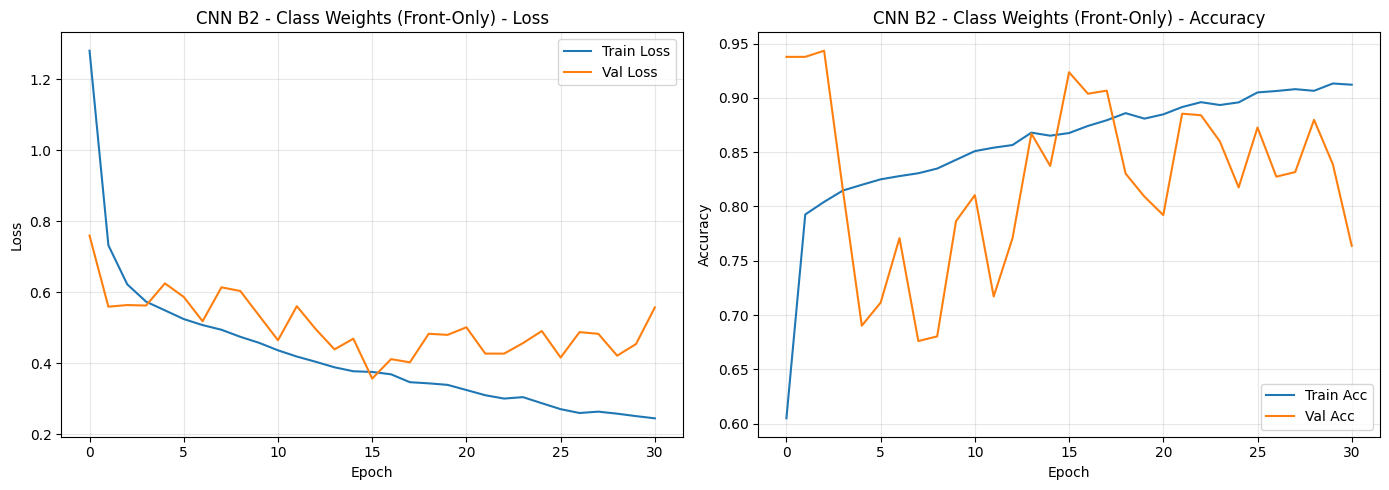

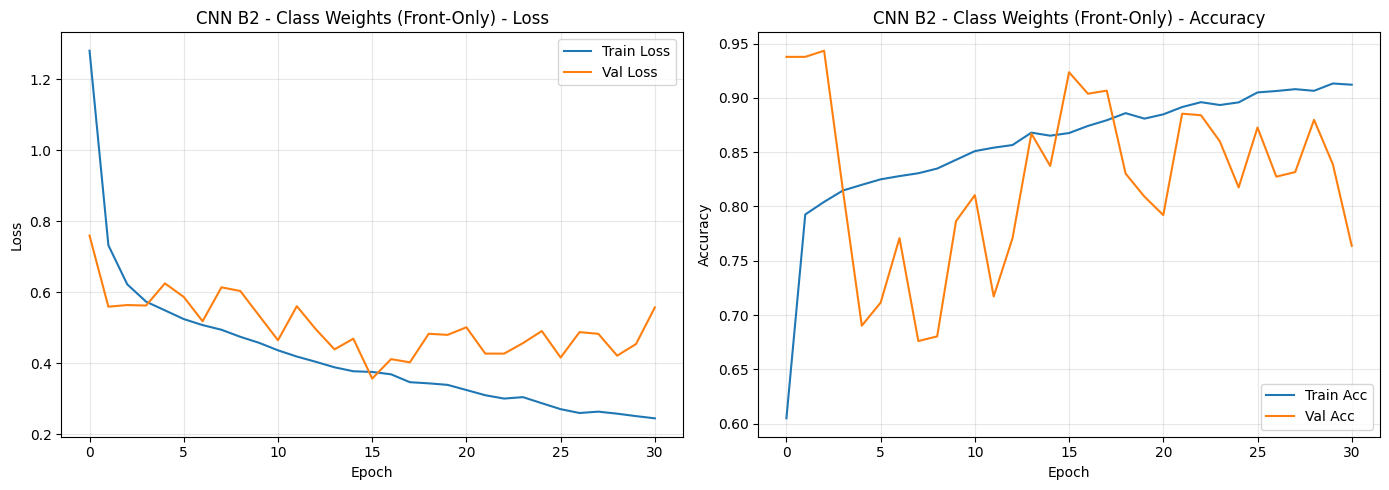

In [6]:
# B2: Class Weights
weights = get_class_weights(DATASET_DIR, device)
print(f"Class weights: {weights}")
criterion = nn.CrossEntropyLoss(weight=weights)

model = EmotionCNN(num_classes=NUM_CLASSES).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-7)

print("\nTraining CNN B2 - Class Weights (Front-Only)...")
history, best_epoch = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "cnn_b2.pth"))

plot_training_history(history, "CNN B2 - Class Weights (Front-Only)")

EVALUASI B2 - CLASS WEIGHTS


Test Loss: 0.3319
Test Accuracy: 0.9054
Test Macro F1: 0.1366
Test Weighted F1: 0.9054

Classification Report:
              precision    recall  f1-score   support

     neutral       0.96      0.96      0.96       981
       happy       0.00      0.00      0.00        10
         sad       0.00      0.00      0.00        29
       angry       0.00      0.00      0.00        10
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         3
   surprised       0.00      0.00      0.00         2

    accuracy                           0.91      1036
   macro avg       0.14      0.14      0.14      1036
weighted avg       0.91      0.91      0.91      1036



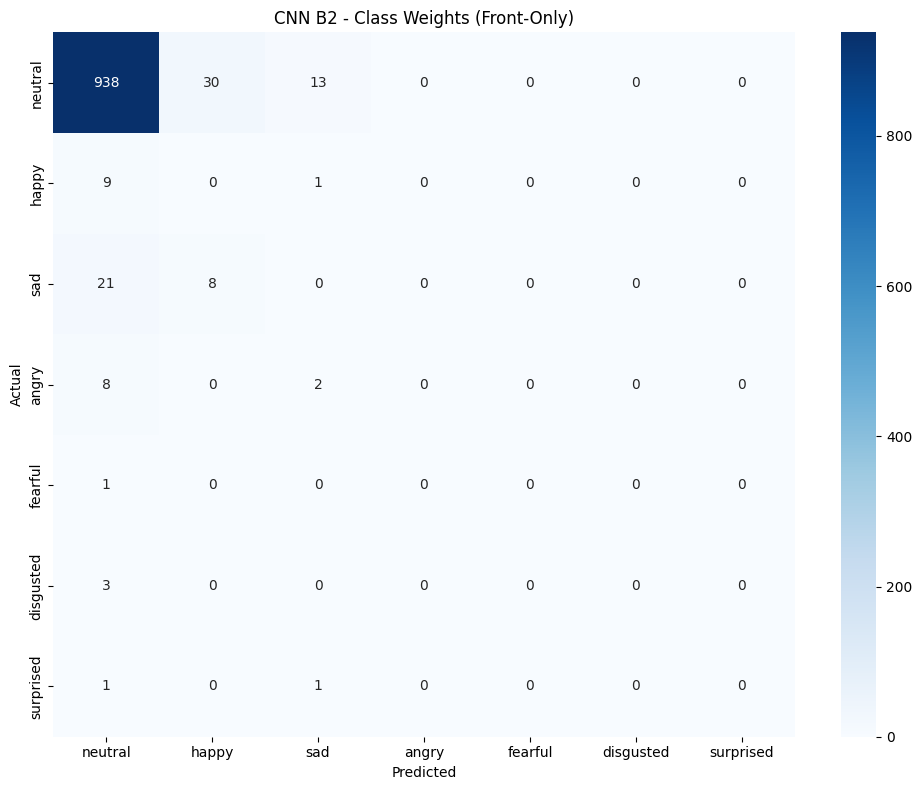

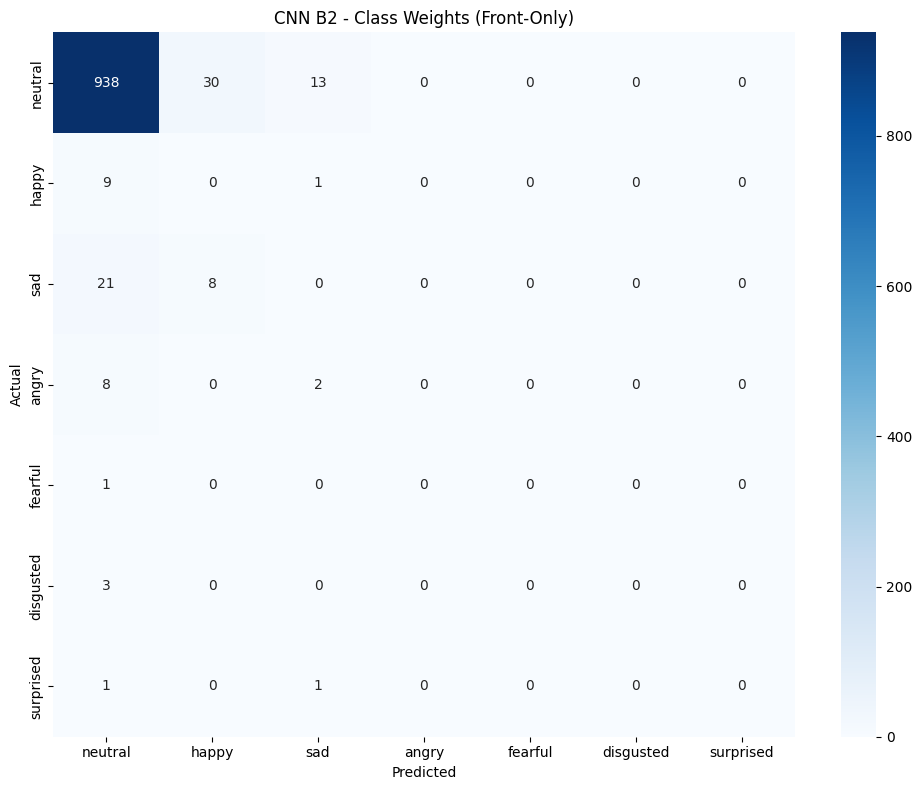

In [7]:
# Evaluate B2
model.load_state_dict(torch.load(OUTPUT_DIR / "cnn_b2.pth", map_location=device, weights_only=True))
print("=" * 60)
print("EVALUASI B2 - CLASS WEIGHTS")
print("=" * 60)
results_b2 = full_evaluation(model, test_loader, criterion, device, "cnn", EMOTIONS)
plot_confusion_matrix(results_b2["confusion_matrix"], "CNN B2 - Class Weights (Front-Only)", EMOTIONS)

## Skenario B3: Class Weights + Augmentasi

Train: 5834 | Val: 707 | Test: 1036
     neutral: 4192
       happy: 660
         sad: 382
       angry: 150
     fearful: 150
   disgusted: 150
   surprised: 150
Augmented class weights: None


Model parameters: 26,999,463

Training CNN B3 - Weights + Augmentasi (Front-Only)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.3344     0.5692     0.7689    0.9378   0.1383   0.000100  (37.7s)


     2      0.8854     0.7353     0.7099    0.9378   0.1499   0.000100  (39.9s)


     3      0.7873     0.7477     0.6936    0.9236   0.1592   0.000100  (37.9s)


...

    19      0.2973     0.8953     0.8508    0.6124   0.1786   0.000050  (37.8s)


    20      0.2815     0.9035     0.8082    0.6478   0.1865   0.000050  (37.7s)


    21      0.2729     0.9037     0.6528    0.7709   0.1836   0.000050  (37.6s)


    22      0.2601     0.9122     0.9275    0.5757   0.1543   0.000050  (37.6s)


    23      0.2416     0.9167     0.7567    0.6789   0.1780   0.000050  (37.6s)

Early stopping at epoch 23. Best epoch: 8 (val_f1=0.2643)

Best: epoch 8, val_acc=0.9250, val_f1=0.2643
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/7class/cnn_b3.pth


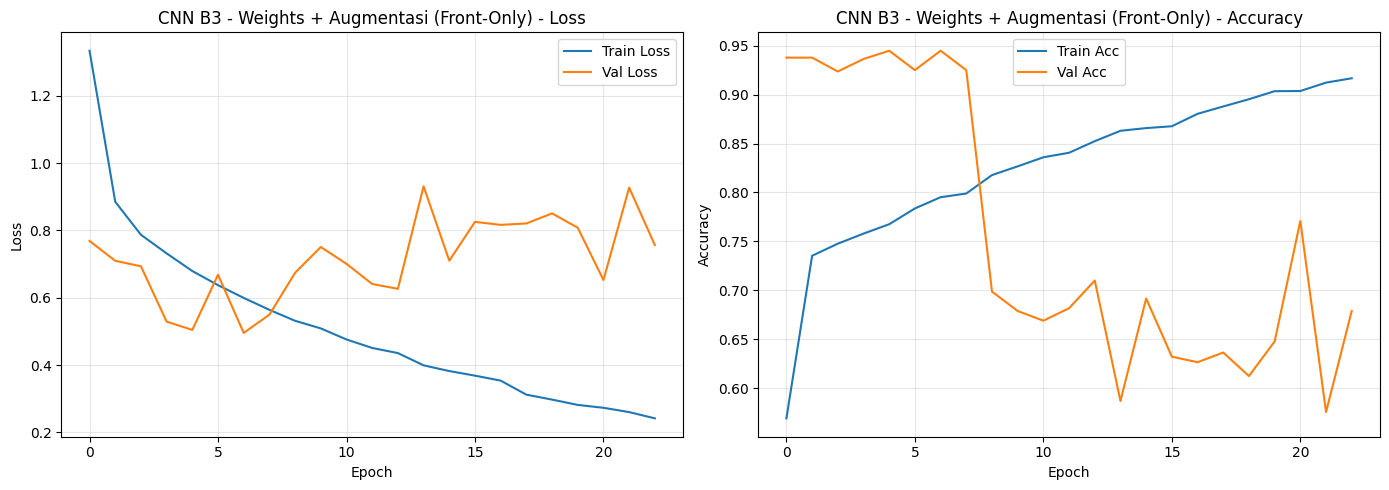

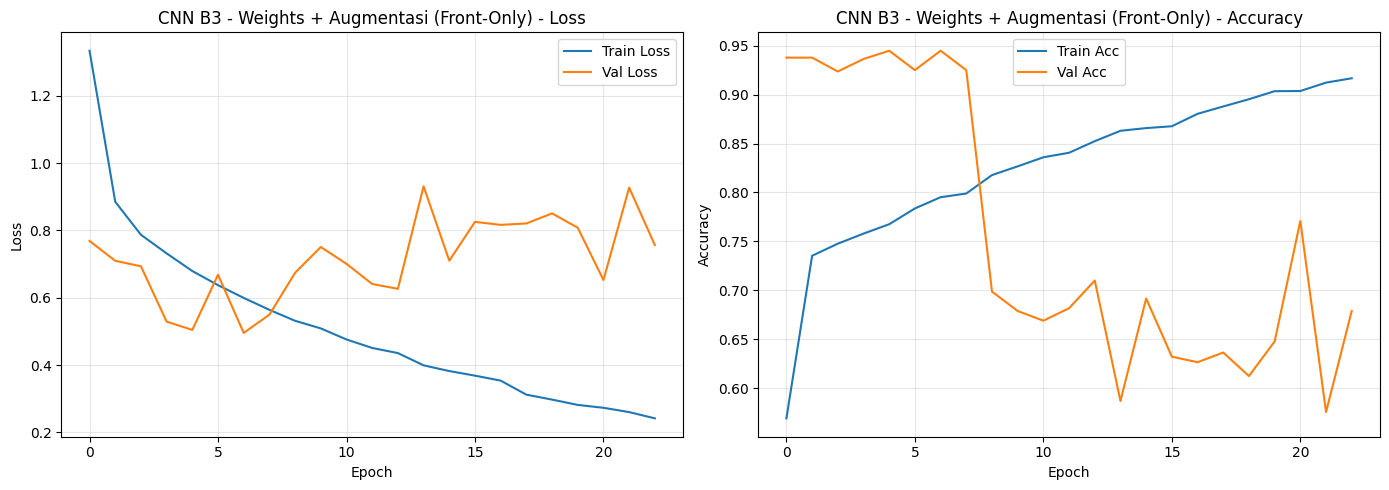

In [8]:
# B3: Weights + Augmentasi
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
print(f"Augmented class weights: {weights_aug}")
criterion = nn.CrossEntropyLoss(weight=weights_aug)

model = EmotionCNN(num_classes=NUM_CLASSES).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-7)

print("\nTraining CNN B3 - Weights + Augmentasi (Front-Only)...")
history, best_epoch = train_model(
    model, train_loader_aug, val_loader, criterion, optimizer, scheduler,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "cnn_b3.pth"))

plot_training_history(history, "CNN B3 - Weights + Augmentasi (Front-Only)")

EVALUASI B3 - WEIGHTS + AUGMENTASI


Test Loss: 0.4902
Test Accuracy: 0.8929
Test Macro F1: 0.1361
Test Weighted F1: 0.9021

Classification Report:
              precision    recall  f1-score   support

     neutral       0.96      0.94      0.95       981
       happy       0.00      0.00      0.00        10
         sad       0.00      0.00      0.00        29
       angry       0.00      0.00      0.00        10
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         3
   surprised       0.00      0.00      0.00         2

    accuracy                           0.89      1036
   macro avg       0.14      0.13      0.14      1036
weighted avg       0.91      0.89      0.90      1036



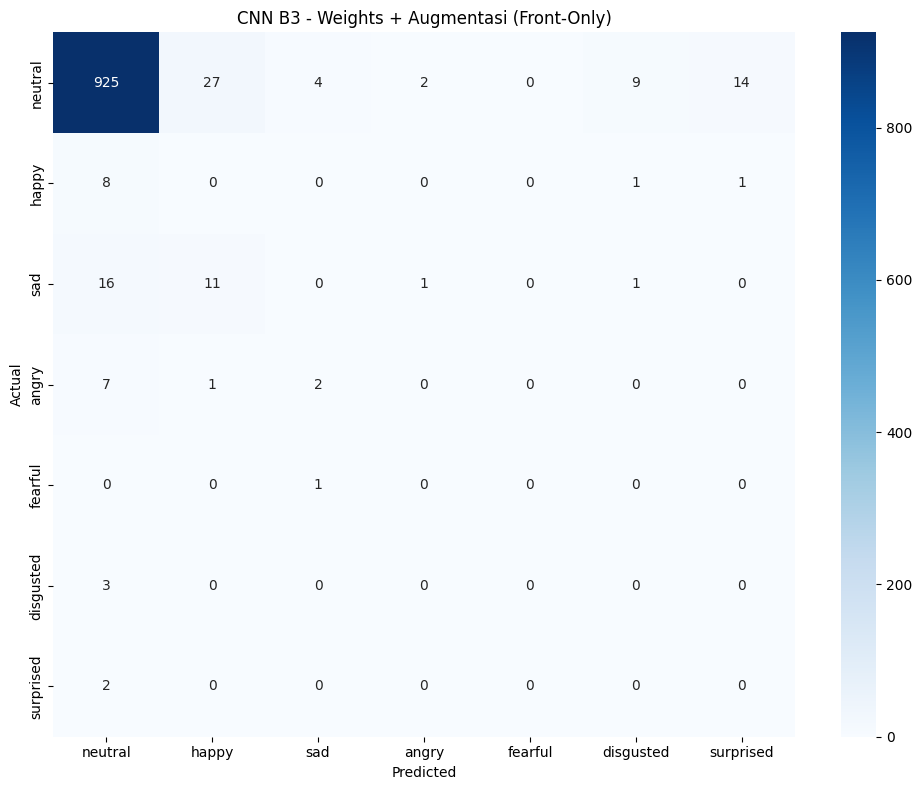

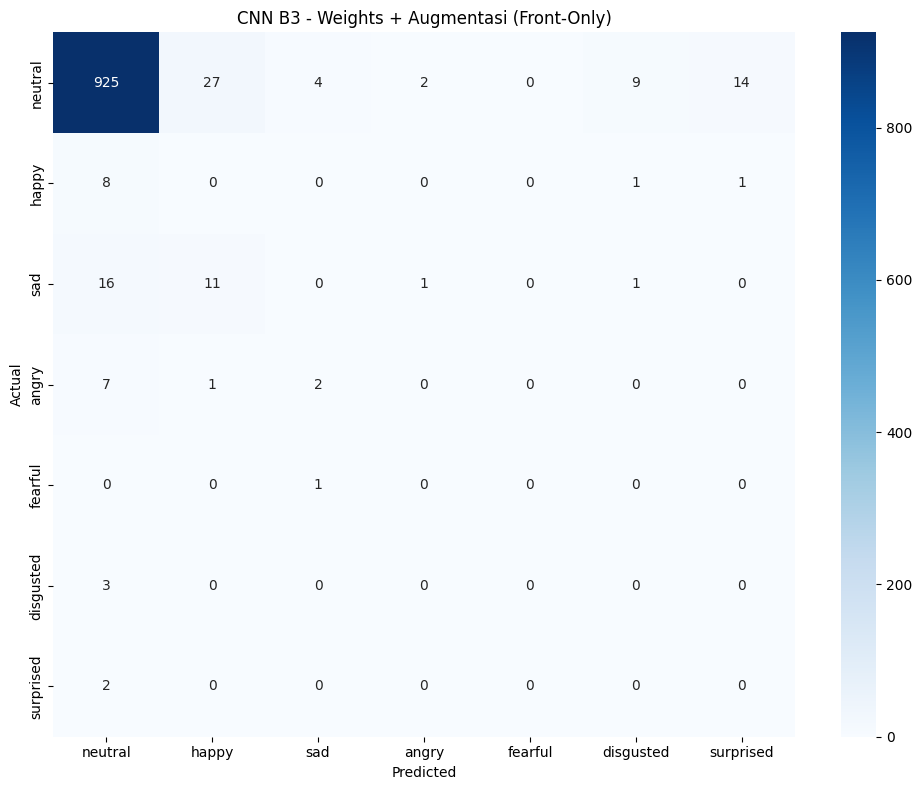

In [9]:
# Evaluate B3
model.load_state_dict(torch.load(OUTPUT_DIR / "cnn_b3.pth", map_location=device, weights_only=True))
print("=" * 60)
print("EVALUASI B3 - WEIGHTS + AUGMENTASI")
print("=" * 60)
results_b3 = full_evaluation(model, test_loader, criterion, device, "cnn", EMOTIONS)
plot_confusion_matrix(results_b3["confusion_matrix"], "CNN B3 - Weights + Augmentasi (Front-Only)", EMOTIONS)

## Perbandingan 3 Skenario

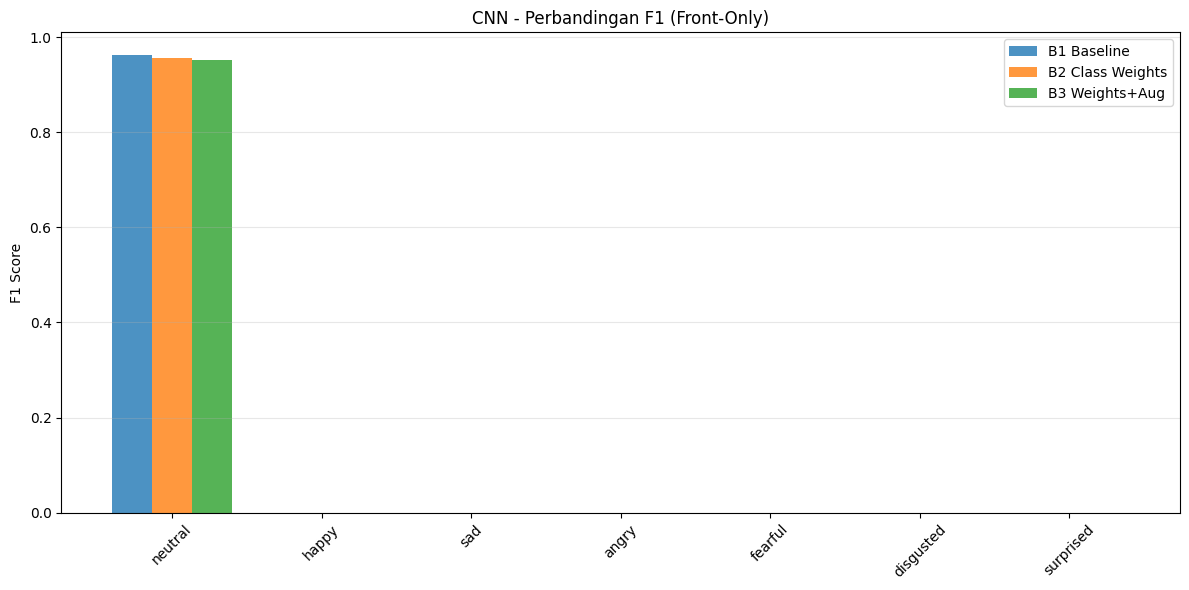

RINGKASAN CNN FRONT-ONLY
Skenario                    Accuracy   Macro F1  Weighted F1
----------------------------------------------------------------------
B1 Baseline                   0.9180     0.1374       0.9110
B2 Class Weights              0.9054     0.1366       0.9054
B3 Weights+Aug                0.8929     0.1361       0.9021

Saved to /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/7class/cnn_results.json


In [10]:
# Perbandingan
all_results = {
    "B1 Baseline": results_b1,
    "B2 Class Weights": results_b2,
    "B3 Weights+Aug": results_b3,
}
plot_per_class_f1(all_results, "CNN - Perbandingan F1 (Front-Only)")

print("=" * 70)
print("RINGKASAN CNN FRONT-ONLY")
print("=" * 70)
print(f"{'Skenario':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 70)
for name, r in all_results.items():
    print(f"{name:<25} {r['test_accuracy']:>10.4f} {r['test_macro_f1']:>10.4f} {r['test_weighted_f1']:>12.4f}")

results_save = {}
for name, r in all_results.items():
    results_save[name] = {
        "accuracy": float(r["test_accuracy"]),
        "macro_f1": float(r["test_macro_f1"]),
        "weighted_f1": float(r["test_weighted_f1"]),
    }
with open(OUTPUT_DIR / "cnn_results.json", "w") as f:
    json.dump(results_save, f, indent=2)
print(f"\nSaved to {OUTPUT_DIR / 'cnn_results.json'}")